# Comparison Smoothing

This notebook demonstrates and compares different smoothing techniques for irradiance estimation in optical simulations using the `diffinytrace` package.

It runs locally and is intended for development, analysis, and visualization of how various smoothing kernels affect the accuracy and convergence of irradiance distributions.  
All computations and results are saved to the local filesystem.


In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


#torch.set_default_device("cuda:0")
device = "cuda:0"
aperture_radius = 12.7
#NBK7 = dit.materials["NBK7"]
#dit.plotting.wavelength.plot(NBK7)

dit_nbk7 = dit.RefractiveIndex(lambda x:1.5046606373973115 + 4215.6909567737075 / (x*1000)**2,[0.1,1.5])
dit_air = dit.RefractiveIndex(lambda x:1.000293,[0.1,1.5])


import os
results_folder = "results/comparison_smoothing/"
try:
    os.mkdir("results")
except:
    pass
try:
    os.mkdir(results_folder)
except:
    pass


In [2]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,dit_nbk7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

det_aperture_radius = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,det_aperture_radius)

#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},dit_air)
system = system.to(device)

In [3]:
num_pix = 32
__gridxt = torch.linspace(-det_aperture_radius,det_aperture_radius,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 32 grid_delta tensor(0.4097)


In [4]:

x,weights = light_source.sample(30)
x = x.to(device)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
#dit.plotting.system2D.plot(system,RayPaths)

In [5]:
def u_mapping(x):
    O,D,wave_len,_,RayPaths = system(x,sequence)
    O_local = detector.to_local_pos(O)
    return O_local[:,[0,1]],O
    

In [6]:

u_mapping(x)

(tensor([[-1.5638,  2.7596],
         [ 1.7473,  3.5387],
         [ 2.5136,  3.6357],
         [-3.1420, -3.1167],
         [ 1.9086,  0.3393],
         [-3.0268,  3.2474],
         [-2.4628, -3.3165],
         [-2.4895, -3.3739],
         [-2.4565,  1.0673],
         [ 0.0619, -3.4365],
         [ 2.0776, -1.8816],
         [ 1.7188,  0.1547],
         [ 1.9395,  1.2306],
         [-0.1576,  3.6853],
         [ 0.5947,  1.3937],
         [-3.5541, -0.3526],
         [-2.4887,  0.8416],
         [-1.4008, -2.4535],
         [-2.6326,  2.8752],
         [ 3.5201,  1.4936],
         [-1.5812,  0.2741],
         [ 2.3551, -2.8598],
         [-2.8790,  3.5133],
         [-3.3733,  0.7099],
         [-1.4172, -0.0207],
         [-2.2006, -2.3489],
         [-2.4489,  3.7386],
         [-0.6041, -4.2227],
         [ 1.6754,  4.1486],
         [-4.5737, -0.8805]], device='cuda:0', grad_fn=<IndexBackward0>),
 tensor([[-1.5638e+00,  2.7596e+00,  2.5000e+01],
         [ 1.7473e+00,  3.5387e+00,

<Figure size 640x480 with 0 Axes>

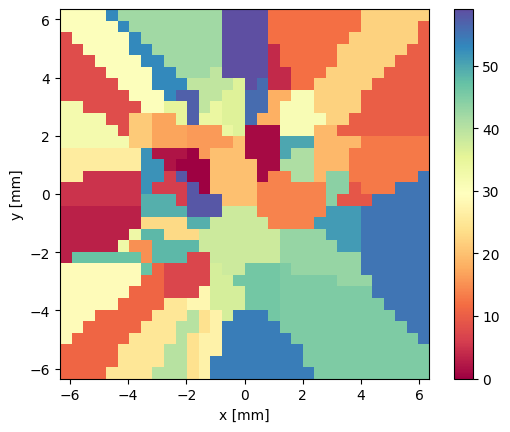

In [7]:
import matplotlib.pyplot as plt

#grid = dit.target_grid.GridSquare(detector.aperture_radius,64)

grid = dit.target_grid.GridSquare(det_aperture_radius,num_pix)

from matplotlib.colors import LogNorm
num_rays = 10*6
x,weights = light_source.sample(num_rays)
x = x*1.1

x = x.to(device)
weights = weights.to(device)
O,D,wave_len,_,RayPaths = system(x,sequence)
O_local = detector.to_local_pos(O)
O_local = O_local[:,[0,1]]
nearest_ray = grid.get_nearest_ray(O_local.detach().cpu()).to("cuda:0")
num_rays_on_grid = grid.sum(O_local,torch.ones((x.shape[0]),dtype=x.dtype,device=x.device))
dit.plotting.quantity2D.plot(nearest_ray,"",[-detector.aperture_radius,detector.aperture_radius],show=False,cmap="Spectral")


In [8]:

x,weights = light_source.sample(1000*1000)
x = x.to(device)
weights = weights.to(device)

O,D,wave_len,_,RayPaths = system(x,sequence)
O_local = detector.to_local_pos(O)
_,org_args = grid.nearest(O_local[:,[0,1]].cpu(),return_args=True)
org_args = org_args.reshape(-1)
mask = org_args==-1

args = org_args[mask!=True]
xb = x.detach()
xb = xb[args]



In [10]:

def one_iter(x_in):
    y = u_mapping(x_in)[0]
    _,org_args = grid.nearest(y[:,[0,1]].cpu(),return_args=True)
    org_args = org_args.reshape(-1)
    mask = org_args==-1
    args = org_args[mask!=True]
    x = x_in.detach()
    x = x[args]
    
    yi,xi = grid.get_yi_xi(y.detach().cpu()[args])
    xmiddle = grid.get_x_middle()
    xmiddle = xmiddle[xi].to(device)
    
    ymiddle = grid.get_y_middle()
    ymiddle = ymiddle[yi].to(device)
    
    x.requires_grad = True
    y = u_mapping(x)[0]
    y = y- torch.stack((xmiddle,ymiddle),dim=1)
    dy1_dx, = dit.grad(y[:,0],inputs=[x],grad_outputs=torch.ones_like(y[:,0]))
    dy2_dx, = dit.grad(y[:,1],inputs=[x],grad_outputs=torch.ones_like(y[:,1]))
    dy_dx = torch.zeros((x.shape[0],2,2),device=device)
    dy_dx[:,0] = dy1_dx
    dy_dx[:,1] = dy2_dx
    H = torch.det(dy_dx).reshape(-1)
    dy_dx_inv = torch.zeros((x.shape[0],2,2),device=device)
    dy_dx_inv[:,0,0 ]= dy_dx[:,1,1]
    dy_dx_inv[:,0,1] = -dy_dx[:,0,1]
    dy_dx_inv[:,1,0] = -dy_dx[:,1,0]
    dy_dx_inv[:,1,1] = dy_dx[:,0,0]
    dy_dx_inv = dy_dx_inv/H.reshape(-1,1,1)
    print(torch.max(torch.abs(y)))
    return x.detach()-torch.bmm(dy_dx_inv,y.reshape(-1,2,1)).reshape(-1,2)


x = xb.detach()
for k in range(10):
    x = one_iter(x)

xb = x.detach()


tensor(0.1984, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.0575, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.0327, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(3.0545e-06, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(4.0345e-11, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(5.3291e-15, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(4.4409e-15, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(4.4409e-15, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(4.4409e-15, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(4.4409e-15, device='cuda:0', grad_fn=<MaxBackward1>)


<Figure size 640x480 with 0 Axes>

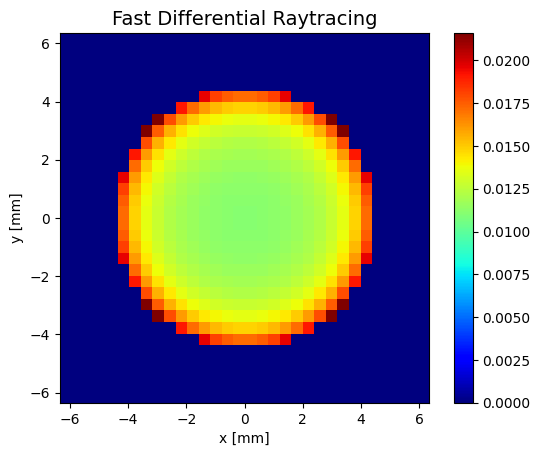

In [11]:
xb = x.detach()
O,D,wave_len,_,RayPaths = system(xb,sequence)
xb = xb[RayPaths["valid"]].clone()
xb.requires_grad = True
O,D,wave_len,_,RayPaths = system(xb,sequence)


O_local = detector.to_local_pos(O)
O1x, = dit.grad(O_local[:,0],xb,torch.ones_like(O_local[:,0]))
O2x, = dit.grad(O_local[:,1],xb,torch.ones_like(O_local[:,1]))

a = O1x[:,0]
b = O1x[:,1]
c = O2x[:,0]
d = O2x[:,1]
H = a*d-b*c

Qval = light_source.get_flux(xb.detach())
    
I = grid.mean(O_local[:,[0,1]],Qval/torch.abs(H))
I_fast = I.detach()
dit.plotting.quantity2D.plot(I_fast,"Fast Differential Raytracing",[-detector.aperture_radius,detector.aperture_radius])


100%|██████████| 100/100 [00:03<00:00, 30.93it/s]


<Figure size 640x480 with 0 Axes>

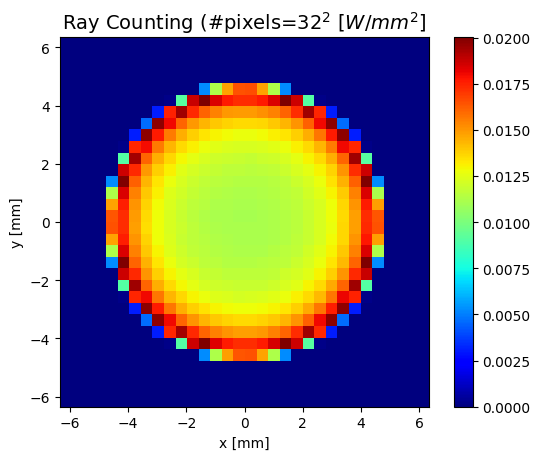

In [ ]:
import numpy as np
import torch
import tqdm
from diffinytrace.render import binned_irradiance


grid = dit.target_grid.GridSquare(det_aperture_radius,num_pix)
raycounting_list = []
for k in tqdm.tqdm(range(1000)):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=1000000,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    raycounting_list.append(tmp)
raycounting = torch.mean(torch.stack(raycounting_list),dim=0).detach().cpu()


dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting (#pixels=${grid.x_grid_size}^2$",[-det_aperture_radius,det_aperture_radius])



In [13]:
smooth_baseline_dict = {}

maxirr_est = (1/(det_aperture_radius*2)**2)*10
sigmas = [0.1,0.2,0.5]

def desired_irradiance_fun(x):
        device = x.device
        dtype = x.dtype
        
        x = torch.clamp(x, min=-det_aperture_radius, max=det_aperture_radius)
        k = grid.get_k(x,round_to_bounds=True)
        k = k.cpu()
        
        out = raycounting.reshape(-1)[k]
        out = out.to(device=device,dtype=dtype)
        return out
    
"""
Here we reuse the implementation of calculating the desired irradiance, to smooth the raycounting result.
"""
dtype = torch.float64
for sigma in tqdm.tqdm(sigmas):

    smoother = dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2**21,smoothed_num_splits=10,device="cpu")
    #.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,device="cpu",desired_irradiance_func=desired_irradiance_func)
    integrator = dit.integrators.Cube([smoother.x_range, smoother.y_range])
        
    with torch.no_grad():
        y,weights = integrator.sample([grid.x_grid_size,grid.y_grid_size],"midpoint")
        y = y.to(device="cpu",dtype=dtype)
        weights = weights.to(device="cpu",dtype=dtype)
        val_multi = desired_irradiance_fun(y)*weights
        tmp_multi = (1./torch.sum(val_multi)).detach().cpu()

        val_multi = val_multi*tmp_multi

        tmp = smoother.smoothed_irradiance(y,val_multi)
        smooth_baseline_dict[sigma] = tmp


100%|██████████| 3/3 [00:07<00:00,  2.39s/it]


In [ ]:
import gc


def render_sigmas_num_rays_batched(num_rays,num_batches):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    binned_irradiance_out = tmp

    quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
    get_smoother = lambda sigma: dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2,smoothed_num_splits=1,device="cpu")
    all_smoothed_irr_ = {}


    #midcut = 0.1
    #num_points_left = 10
    #num_points_right = 10 
    #all_sigmas = list(np.linspace(0.05,midcut,num_points_left))+list(np.linspace(midcut,0.5,num_points_right))
    all_sigmas = list(np.linspace(0.1,0.5,20))
    for sigma in all_sigmas:
        smoother = get_smoother(sigma)
        total_tmp = []
        for k in tqdm.tqdm(range(num_batches)):
            
            tmp = quick_render(num_rays,smoother)
            tmp = tmp.detach().cpu()
            total_tmp.append(tmp)
        all_smoothed_irr_[sigma] = torch.mean(torch.stack(total_tmp),dim=0)

    gc.collect()
    out = {"binned_irradiance":binned_irradiance_out,"all_smoothed_irr":all_smoothed_irr_}
    return out
results_high_rays = render_sigmas_num_rays_batched(1000000,1000)

100%|██████████| 100/100 [00:30<00:00,  3.23it/s]


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\marti\AppData\Local\Temp\ipykernel_25772\251940686.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma$ [mm]')#, fontsize=14


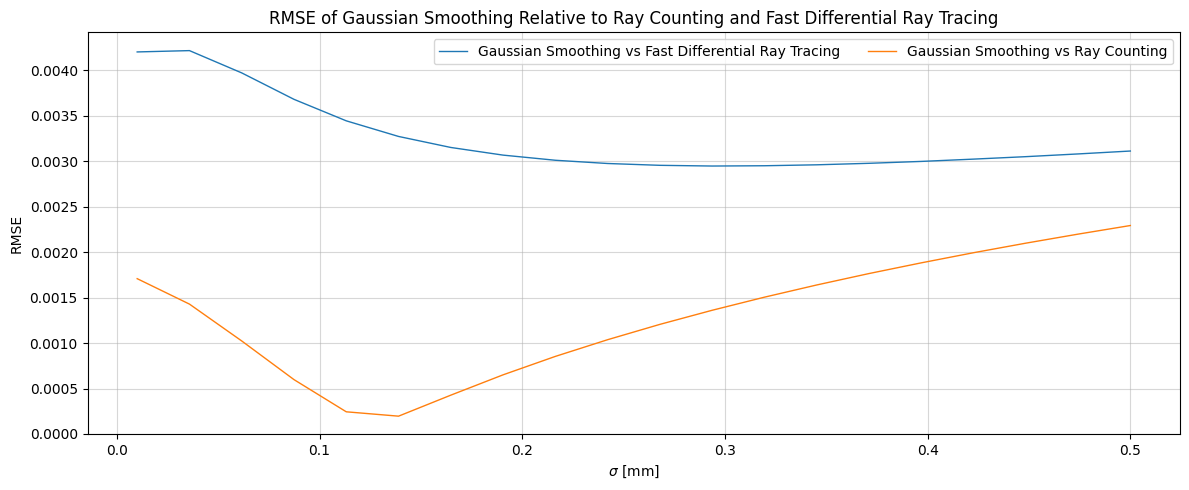

In [ ]:
import matplotlib.pyplot as plt
I_fast = I_fast.cpu()

plt.figure(figsize=(12,5))

binned_irradiance_out = results_high_rays["binned_irradiance"]
all_smoothed_irr_ = results_high_rays["all_smoothed_irr"]

sigmas = np.sort(list(all_smoothed_irr_.keys()))[::-1]
#rmse_fun = lambda irr: torch.sqrt(torch.mean((irr*(I_fast!=0)-I_fast)**2.0))
#rmse_elems = [rmse_fun(all_smoothed_irr_[sigma]) for sigma in sigmas]
#plt.plot(sigmas, rmse_elems,'-',linewidth=1, markersize=4,alpha=1)


rmse_fun = lambda irr: torch.sqrt(torch.mean((irr-raycounting)**2.0))
rmse_elems = [rmse_fun(all_smoothed_irr_[sigma]) for sigma in sigmas]
plt.plot(sigmas, rmse_elems,'-',linewidth=1, markersize=4,alpha=1,label="ray counting")

plt.title('RMSE of Fast Differential Raytracing vs Gaussian Smoothing')#fontsize=16
plt.xlabel('$\sigma$ [mm]')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"convergence_smoothing_to_binned_L.png", dpi=400, bbox_inches='tight')